In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
import re

def clean_text(text):
    """Заменяем переносы строк и табуляции на пробелы"""
    if isinstance(text, str):
        text = re.sub(r'\n|\r|\t', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    return text


cols = ['text', 'label', 'model'] if 'model' in pd.read_csv(
    'llmtrace_news.csv', nrows=0).columns else ['text', 'label']
df = pd.read_csv('llmtrace_news.csv', usecols=cols)
df['text'] = df['text'].fillna('').apply(clean_text)

# Фильтруем по длине
df['wc'] = df['text'].str.split().str.len()
df = df[df['wc'] >= 50].drop(columns='wc').reset_index(drop=True)

df_human = df[df['label'] == 'human']
df_ai = df[df['label'] == 'ai']

print("Модели генерации до фильтрации:")
if 'model' in df.columns:
    print(df_ai['model'].value_counts())

# Фильтруем по моделям (>=700 текстов)
if 'model' in df.columns:
    model_counts = df_ai['model'].value_counts()
    models_to_keep = model_counts[model_counts >= 700].index
    df_ai = df_ai[df_ai['model'].isin(models_to_keep)]
print("Модели генерации после фильтрации:")
print(df_ai['model'].value_counts()) 

human_texts = df_human['text'].tolist()
ai_texts    = df_ai['text'].tolist()

print(f"\nПосле фильтрации: human={len(human_texts)}, ai={len(ai_texts)}")
# Балансировка
n_samples = min(len(human_texts), len(ai_texts))
print(f"\nБалансировка: берем {n_samples} текстов каждого класса")

import random

if len(ai_texts) > n_samples:
    ai_texts = random.sample(ai_texts, n_samples)
else:
    human_texts = random.sample(human_texts, n_samples)


# Разделение 70/15/15
human_train, human_temp = train_test_split(human_texts, test_size=0.3, random_state=42, shuffle=True)
human_val, human_test = train_test_split(human_temp, test_size=0.5, random_state=42, shuffle=True)

ai_train, ai_temp = train_test_split(ai_texts, test_size=0.3, random_state=42, shuffle=True)
ai_val, ai_test = train_test_split(ai_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"\nРазделение (сбалансированное):")
print(f"  Обучение: human={len(human_train)}, ai={len(ai_train)}")
print(f"  Валидация: human={len(human_val)}, ai={len(ai_val)}")
print(f"  Тест: human={len(human_test)}, ai={len(ai_test)}")

# Проверка баланса
print(f"\nПроверка баланса:")
print(f"  Обучение: human/ai = {len(human_train)}/{len(ai_train)} = {len(human_train)/len(ai_train):.2f}")
print(f"  Валидация: human/ai = {len(human_val)}/{len(ai_val)} = {len(human_val)/len(ai_val):.2f}")
print(f"  Тест: human/ai = {len(human_test)}/{len(ai_test)} = {len(human_test)/len(ai_test):.2f}")

# Средняя длина текста на обучении
train_texts_all = human_train + ai_train
train_lengths = [len(text.split()) for text in train_texts_all]
print(f"\nСредняя длина текста в обучающей выборке: {np.mean(train_lengths):.1f} слов")
print(f"  Мин/Макс: {np.min(train_lengths)} / {np.max(train_lengths)}")

# Удаляем старые файлы
for f in ['train_texts.txt', 'val_human.txt', 'val_ai.txt', 'test_human.txt', 'test_ai.txt']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Удален {f}")

# Сохраняем файлы
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in human_train + ai_train:
        f.write(clean_text(text) + '\n')

with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(clean_text(text) + '\n')

with open('val_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_val:
        f.write(clean_text(text) + '\n')

with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in human_test:
        f.write(clean_text(text) + '\n')

with open('test_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_test:
        f.write(clean_text(text) + '\n')

print("\nФайлы сохранены:")
print(f"  train_texts.txt: {len(human_train)+len(ai_train)} текстов")
print(f"  val_human.txt: {len(human_val)} текстов")
print(f"  val_ai.txt: {len(ai_val)} текстов")
print(f"  test_human.txt: {len(human_test)} текстов")
print(f"  test_ai.txt: {len(ai_test)} текстов")

Модели генерации до фильтрации:
model
gpt-3.5                                     838
CohereForAI/c4ai-command-r-08-2024          792
yandex/YandexGPT-5-Lite-8B-instruct         778
unsloth/Llama-3.3-70B-Instruct              778
google/gemma-2-27b-it                       778
01-ai/Yi-1.5-34B-Chat                       762
WizardLM-2-7B                               761
Qwen/QwQ-32B                                760
databricks/dbrx-instruct                    756
Qwen/Qwen2.5-72B-Instruct                   749
Meta-Llama-3-8B-Instruct                    723
mistralai/Ministral-8B-Instruct-2410        721
GigaChat-Max                                567
gemma-1.1-7b-it                             514
deepseek-ai/DeepSeek-R1-Distill-Qwen-32B    495
ruGPT                                       481
gigachat                                    442
yagpt                                       223
llama-7b                                    205
gpt-4-0125-preview                          136
gp

In [2]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 3261591 types 332246
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:3986952 2:1141185024 3:2139721856
Statistics:
1 332246 D1=0.689397 D2=1.03632 D3+=1.44194
2 1772666 D1=0.843495 D2=1.19293 D3+=1.40494
3 2691703 D1=0.865999 D2=1.44157 D3+=1.72894
Memory estimate for binary LM:
type     MB
probing  95 assuming -p 1.5
probing 106 assuming -r models -p 1.5
trie     45 without quantization
trie     28 assuming -q 8 -b 8 quantization 
trie     42 assuming -a 22 array pointer compression
trie     25 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:398

In [3]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [4]:
import numpy as np
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_ai.txt', 'r', encoding='utf-8') as f:
    val_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, ai={len(val_ai)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_ai_ppl = [get_perplexity(model, text) for text in val_ai]
val_ai_ppl = [x for x in val_ai_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl ai: {np.mean(val_ai_ppl):.2f}")

Валидация: human=1379, ai=1379
  Среднее ppl human: 11.01
  Среднее ppl ai: 7.63


Accuracy порог: 8.31 (acc=0.7266)
F1 порог:       10.80 (f1=0.7320)
AUC порог:   8.31 (auc=0.7894)


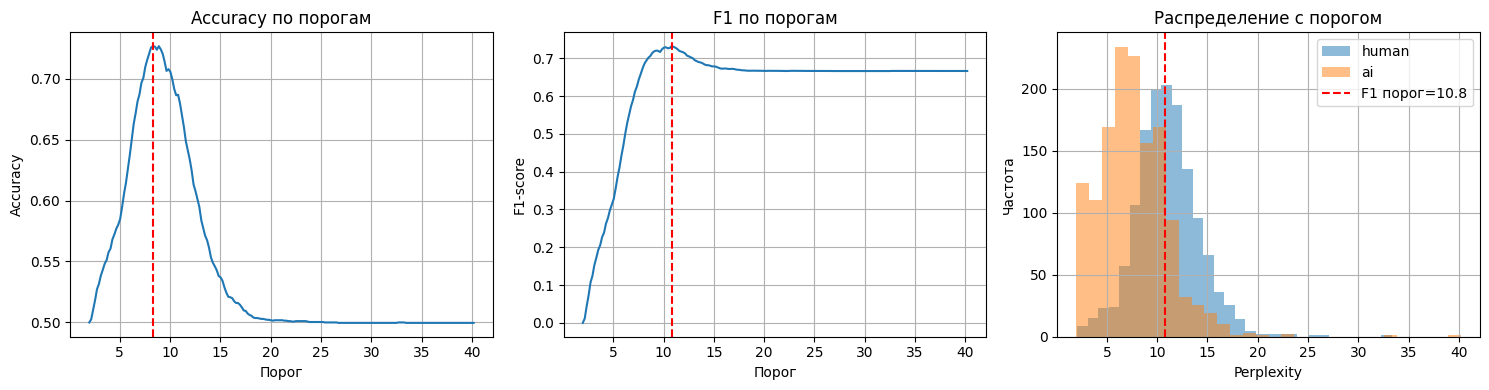

In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_ai_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_ai_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
val_auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"AUC порог:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_ai_ppl, bins=30, alpha=0.5, label='ai')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
with open('test_human.txt', 'r', encoding='utf-8') as f:
    test_human = [line.strip() for line in f.readlines() if line.strip()]

with open('test_ai.txt', 'r', encoding='utf-8') as f:
    test_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Тест: human={len(test_human)}, ai={len(test_ai)}")

test_human_ppl = [get_perplexity(model, text) for text in test_human]
test_human_ppl = [x for x in test_human_ppl if x is not None]

test_ai_ppl = [get_perplexity(model, text) for text in test_ai]
test_ai_ppl = [x for x in test_ai_ppl if x is not None]

print(f"\nТестовая перплексия:")
print(f"  Human среднее: {np.mean(test_human_ppl):.2f}")
print(f"  Llama среднее: {np.mean(test_ai_ppl):.2f}")

Тест: human=1380, ai=1380

Тестовая перплексия:
  Human среднее: 11.23
  Llama среднее: 7.79


In [7]:
test_all_ppl = np.array(test_human_ppl + test_ai_ppl)
y_test_true = [0] * len(test_human_ppl) + [1] * len(test_ai_ppl)

final_threshold = best_thresh_acc
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по Acc: {final_threshold:.2f}")
print(f"Предсказано machine: {sum(y_test_pred)} из {len(y_test_pred)}")

Используем порог по Acc: 8.31
Предсказано machine: 1073 из 2760


In [8]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.7257
F1-score:  0.6914
ROC-AUC:   0.7877

Матрица ошибок:
           Pred human  Pred machine
Actual human     1155        225
Actual machine    532        848


In [9]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7320     0.6914    -0.0406
Accuracy         0.7266     0.7257    -0.0009
ROC-AUC          0.7894     0.7877    -0.0016


/tmp/ipykernel_4528/810686892.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)


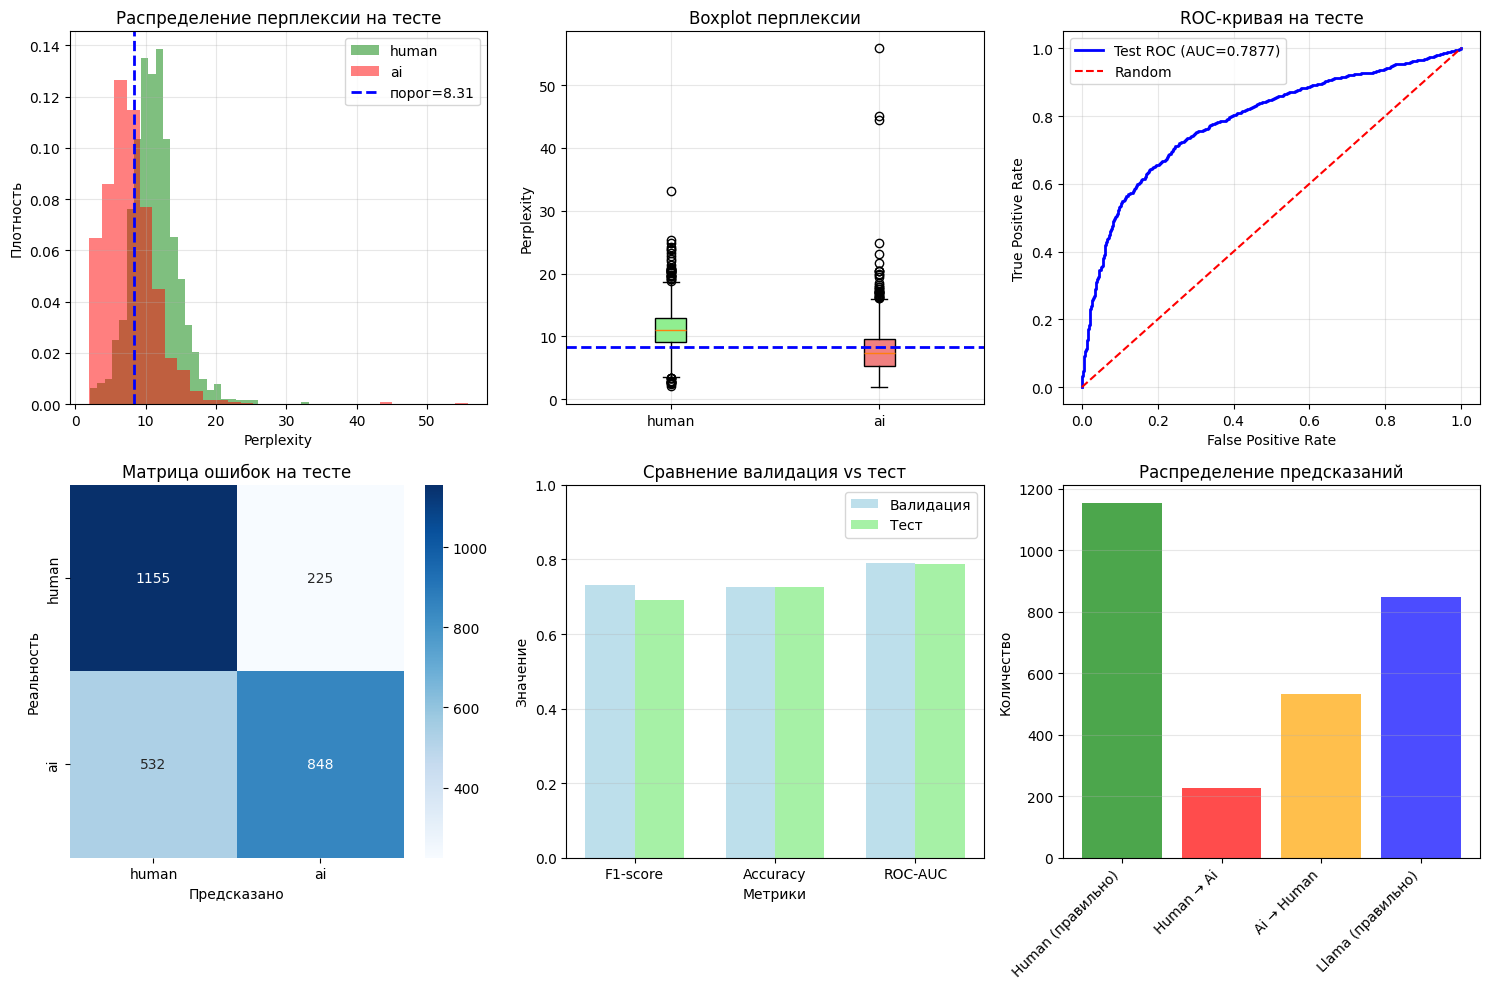


Итоговые метрики на тесте (порог F1=8.31):
  Accuracy: 0.7257
  F1-score: 0.6914
  ROC-AUC:  0.7877


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = test_ai_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='ai', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'ai'], 
            yticklabels=['human', 'ai'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Ai', 'Ai → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")